In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import joblib

In [4]:
processed_dir = Path("D:\Erdos\Data Science Bootcamp\summer26-diabetes-risk\early_diabetes_screening\data\processed")
results_dir = Path(r"D:\Erdos\Data Science Bootcamp\summer26-diabetes-risk\early_diabetes_screening\results")
interpretability_dir = results_dir / "interpretability"
final_dir = results_dir / "final"
modeling_dir = results_dir / "modeling"
artifacts_dir = Path(r"D:\Erdos\Data Science Bootcamp\summer26-diabetes-risk\early_diabetes_screening\artifacts")

results_dir.mkdir(parents=True, exist_ok=True)
interpretability_dir.mkdir(parents=True, exist_ok=True)
final_dir.mkdir(parents=True, exist_ok=True)
modeling_dir.mkdir(parents=True, exist_ok=True)
artifacts_dir.mkdir(parents=True, exist_ok=True)

today = datetime.today().strftime("%Y_%m_%d")

In [6]:
# Load dataset 

X = pd.read_csv(processed_dir / "X_pred_engineered.csv")
y = pd.read_csv(processed_dir / "y_target_selected.csv").squeeze()

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

print(y.value_counts())
print(y.value_counts(normalize=True).round(4))

Predictor shape: (9232, 37)
Target shape: (9232,)
diabetes
0    7412
1    1820
Name: count, dtype: int64
diabetes
0    0.8029
1    0.1971
Name: proportion, dtype: float64


In [7]:
# Final leakage check

leakage_cols = [
    "SEQN",
    "diabetes",
    "doctor_diabetes",
    "DIQ010",
    "LBXGH",
    "LBXGLU"
]
leakage_present = [col for col in leakage_cols if col in X.columns]

print("Leakage columns found in X:")
print(leakage_present)

if len(leakage_present) > 0:
    X = X.drop(columns=leakage_present)
    print("Leakage columns removed.")

print("Final predictor shape:", X.shape)

Leakage columns found in X:
[]
Final predictor shape: (9232, 37)


In [8]:
# Stratified final holdout split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set shape: (7385, 37)
Test set shape: (1847, 37)

Training target distribution:
diabetes
0    0.8028
1    0.1972
Name: proportion, dtype: float64

Test target distribution:
diabetes
0    0.8029
1    0.1971
Name: proportion, dtype: float64


In [9]:
# Define categorical and numeric features

coded_categorical_features = [
    # Original coded categorical variables
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "BPQ020",
    "BPQ080",
    "SMQ020",
    "PAQ650",
    "PAQ665",
    "ALQ111",
    "ALQ121",
    "DBQ700",

    # Engineered categorical / binary indicator variables
    "obese",
    "bmi_category",
    "high_bp_exam",
    "high_waist",
    "physically_active",
    "ever_regular_alcohol",
    "smoking_history",
    "fair_poor_diet",
    "fair_or_poor_diet",
    "frequent_fast_food"
]

categorical_features = [
    col for col in coded_categorical_features
    if col in X_train.columns
]

object_categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_features = sorted(list(set(categorical_features + object_categorical_features)))

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Number of numeric features:", len(numeric_features))
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

Number of numeric features: 17
['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'PAD680', 'ALQ130', 'DBD895', 'DBD900', 'DBD905', 'DBD910', 'avg_systolic_bp', 'avg_diastolic_bp', 'pulse_pressure', 'age_bmi', 'age_waist', 'age_systolic_bp', 'metabolic_risk_score']

Number of categorical features: 20
['ALQ111', 'ALQ121', 'BPQ020', 'BPQ080', 'DBQ700', 'DMDEDUC2', 'PAQ650', 'PAQ665', 'RIAGENDR', 'RIDRETH3', 'SMQ020', 'bmi_category', 'ever_regular_alcohol', 'fair_poor_diet', 'frequent_fast_food', 'high_bp_exam', 'high_waist', 'obese', 'physically_active', 'smoking_history']


In [10]:
# Build preprocessing pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [11]:
# Define CV strategy and KPIs

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score)
}

In [12]:
# Define advanced models

advanced_models = {}

# Regularized Logistic Regression
advanced_models["Regularized Logistic Regression"] = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42,
    solver="saga"
)

# Random Forest
advanced_models["Random Forest"] = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Gradient Boosting
advanced_models["Gradient Boosting"] = GradientBoostingClassifier(
    random_state=42
)

# XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

advanced_models["XGBoost"] = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [13]:
# Define hyperparameter search spaces

param_distributions = {
    "Regularized Logistic Regression": [
        {
            "model__penalty": ["l1", "l2"],
            "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
        },
        {
            "model__penalty": ["elasticnet"],
            "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
            "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    ],

    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 5, 10, 15, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 3, 5, 10],
        "model__max_features": ["sqrt", "log2", None]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__min_samples_leaf": [1, 3, 5, 10],
        "model__subsample": [0.7, 0.8, 1.0]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
        "model__min_child_weight": [1, 3, 5],
        "model__gamma": [0, 0.1, 0.5],
        "model__reg_lambda": [1, 3, 5, 10]
    }
}

In [14]:
# Tune advanced models using RandomizedSearchCV

search_results = []
best_estimators = {}

for model_name, model in advanced_models.items():
    print(f"\nTuning model: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions[model_name],
        n_iter=20,
        scoring=scoring,
        refit="recall",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=False
    )

    search.fit(X_train, y_train)

    best_estimators[model_name] = search.best_estimator_

    best_index = search.best_index_
    row = {
        "model": model_name,
        "model_group": "advanced_model",
        "tuning_type": "RandomizedSearchCV_refit_recall",
        "best_params": search.best_params_
    }

    for metric in scoring.keys():
        row[f"{metric}_mean"] = search.cv_results_[f"mean_test_{metric}"][best_index]
        row[f"{metric}_std"] = search.cv_results_[f"std_test_{metric}"][best_index]

    search_results.append(row)

advanced_results = pd.DataFrame(search_results)

advanced_results_rounded = advanced_results.copy()
num_cols = advanced_results_rounded.select_dtypes(include=["float64"]).columns
advanced_results_rounded[num_cols] = advanced_results_rounded[num_cols].round(4)

advanced_results_rounded[
    ["model", "recall_mean", "pr_auc_mean", "roc_auc_mean",
     "balanced_accuracy_mean", "f1_mean", "precision_mean", "accuracy_mean"]
]


Tuning model: Regularized Logistic Regression
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Tuning model: Random Forest
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Tuning model: Gradient Boosting
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Tuning model: XGBoost
Fitting 5 folds for each of 20 candidates, totalling 100 fits


,model,recall_mean,pr_auc_mean,roc_auc_mean,balanced_accuracy_mean,f1_mean,precision_mean,accuracy_mean
0,Regularized Logistic Regression,0.7582,0.4795,0.8058,0.7319,0.5127,0.3874,0.7159
1,Random Forest,0.7733,0.4680,0.7941,0.7212,0.4955,0.3646,0.6896
2,Gradient Boosting,0.2603,0.4698,0.7982,0.6027,0.3506,0.5377,0.8100
3,XGBoost,0.7953,0.4759,0.7993,0.7306,0.5041,0.3690,0.6914


In [15]:
advanced_model_result_path = modeling_dir / "advanced_results.csv"
advanced_results_rounded.to_csv(advanced_model_result_path, index=False)

In [16]:
# Load baseline results 
baseline_results = pd.read_csv(results_dir / "baseline_cv_results.csv")

baseline_results["model_group"] = "simple_baseline"
baseline_results["tuning_type"] = "not_tuned"
baseline_results["best_params"] = "default_or_simple_settings"

baseline_results

,model,split_strategy,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,model_group,tuning_type,best_params
0,Dummy Classifier,80_20_stratified_holdout_with_5fold_stratified...,0.8028,0.0003,0.5000,0.0000,0.5000,0.0000,0.1972,0.0003,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,simple_baseline,not_tuned,default_or_simple_settings
1,Logistic Regression,80_20_stratified_holdout_with_5fold_stratified...,0.7167,0.0035,0.7300,0.0070,0.8054,0.0085,0.4800,0.0114,0.7520,0.0162,0.3875,0.0047,0.5114,0.0071,simple_baseline,not_tuned,default_or_simple_settings
2,Decision Tree,80_20_stratified_holdout_with_5fold_stratified...,0.6708,0.0184,0.7028,0.0088,0.7635,0.0107,0.4007,0.0175,0.7555,0.0332,0.3471,0.0111,0.4752,0.0093,simple_baseline,not_tuned,default_or_simple_settings


In [17]:
# Combine baseline and advanced results

model_comparison = pd.concat(
    [baseline_results, advanced_results],
    ignore_index=True
)

model_comparison_rounded = model_comparison.copy()
num_cols = model_comparison_rounded.select_dtypes(include=["float64"]).columns
model_comparison_rounded[num_cols] = model_comparison_rounded[num_cols].round(4)

display_cols = [
    "model",
    "model_group",
    "tuning_type",
    "recall_mean",
    "pr_auc_mean",
    "roc_auc_mean",
    "balanced_accuracy_mean",
    "f1_mean",
    "precision_mean",
    "accuracy_mean"
]

modeling_comparison = model_comparison_rounded[display_cols].sort_values(
    by=["recall_mean", "pr_auc_mean"],
    ascending=False
)

,model,model_group,tuning_type,recall_mean,pr_auc_mean,roc_auc_mean,balanced_accuracy_mean,f1_mean,precision_mean,accuracy_mean
6,XGBoost,advanced_model,RandomizedSearchCV_refit_recall,0.7953,0.4759,0.7993,0.7306,0.5041,0.3690,0.6914
4,Random Forest,advanced_model,RandomizedSearchCV_refit_recall,0.7733,0.4680,0.7941,0.7212,0.4955,0.3646,0.6896
3,Regularized Logistic Regression,advanced_model,RandomizedSearchCV_refit_recall,0.7582,0.4795,0.8058,0.7319,0.5127,0.3874,0.7159
2,Decision Tree,simple_baseline,not_tuned,0.7555,0.4007,0.7635,0.7028,0.4752,0.3471,0.6708
1,Logistic Regression,simple_baseline,not_tuned,0.7520,0.4800,0.8054,0.7300,0.5114,0.3875,0.7167
5,Gradient Boosting,advanced_model,RandomizedSearchCV_refit_recall,0.2603,0.4698,0.7982,0.6027,0.3506,0.5377,0.8100
0,Dummy Classifier,simple_baseline,not_tuned,0.0000,0.1972,0.5000,0.5000,0.0000,0.0000,0.8028


In [68]:
model_comparison_path = modeling_dir / "model_comparison.csv"
modeling_comparison.to_csv(model_comparison_path, index=False)

In [19]:
# Prepare model comparison data for plots

plot_df = model_comparison.copy()
metric_cols = [
    "recall_mean",
    "pr_auc_mean",
    "roc_auc_mean",
    "balanced_accuracy_mean",
    "f1_mean",
    "precision_mean",
    "accuracy_mean"
]

plot_df = plot_df[["model"] + metric_cols].copy()
plot_df

,model,recall_mean,pr_auc_mean,roc_auc_mean,balanced_accuracy_mean,f1_mean,precision_mean,accuracy_mean
0,Dummy Classifier,0.000000,0.197200,0.500000,0.500000,0.000000,0.000000,0.802800
1,Logistic Regression,0.752000,0.480000,0.805400,0.730000,0.511400,0.387500,0.716700
2,Decision Tree,0.755500,0.400700,0.763500,0.702800,0.475200,0.347100,0.670800
3,Regularized Logistic Regression,0.758231,0.479472,0.805769,0.731873,0.512747,0.387363,0.715911
4,Random Forest,0.773335,0.468027,0.794056,0.721210,0.495520,0.364618,0.689641
5,Gradient Boosting,0.260323,0.469775,0.798230,0.602669,0.350636,0.537690,0.810020
6,XGBoost,0.795316,0.475874,0.799347,0.730599,0.504058,0.368982,0.691401


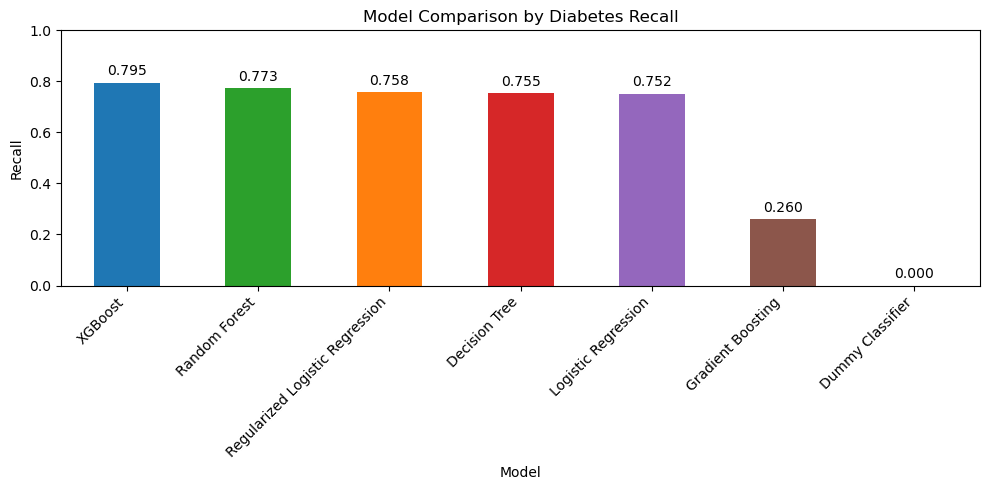

In [20]:
# Recall comparison plot

recall_plot_df = plot_df.sort_values("recall_mean", ascending=False).copy()

colors = [
    "tab:blue",
    "tab:green",
    "tab:orange",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:gray"
]

ax = recall_plot_df.plot(
    x="model",
    y="recall_mean",
    kind="bar",
    color=colors[:len(recall_plot_df)],
    legend=False,
    figsize=(10, 5)
)

plt.title("Model Comparison by Diabetes Recall")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
model_comp_recall_path = modeling_dir / "model_comp_recall.png"
plt.savefig(model_comp_recall_path, dpi=300, bbox_inches="tight")
plt.show()

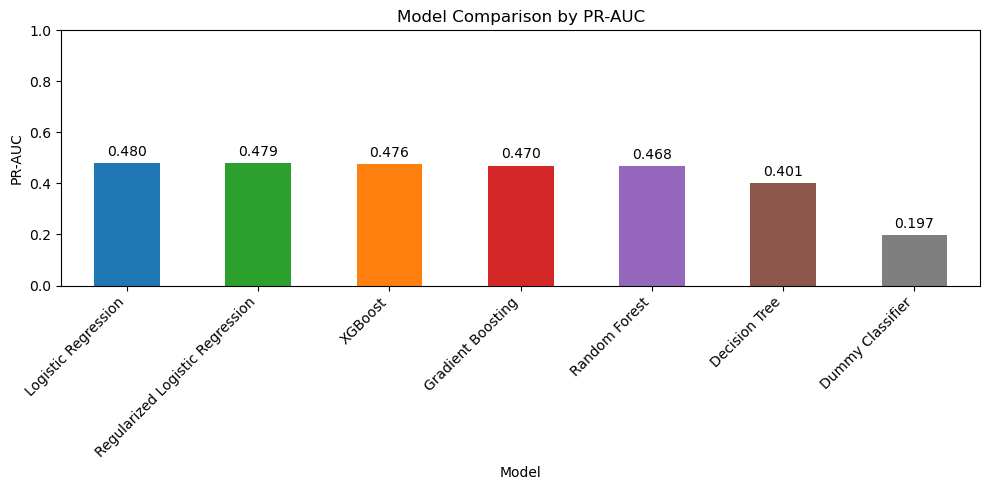

In [21]:
# PR-AUC comparison plot

pr_auc_plot_df = plot_df.sort_values("pr_auc_mean", ascending=False).copy()

colors = [
    "tab:blue",
    "tab:green",
    "tab:orange",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:gray"
]

ax = pr_auc_plot_df.plot(
    x="model",
    y="pr_auc_mean",
    kind="bar",
    color=colors[:len(pr_auc_plot_df)],
    legend=False,
    figsize=(10, 5)
)

plt.title("Model Comparison by PR-AUC")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
model_comp_PRAUC_path = modeling_dir / "model_comp_PRAUC.png"
plt.savefig(model_comp_PRAUC_path, dpi=300, bbox_inches="tight")
plt.show()

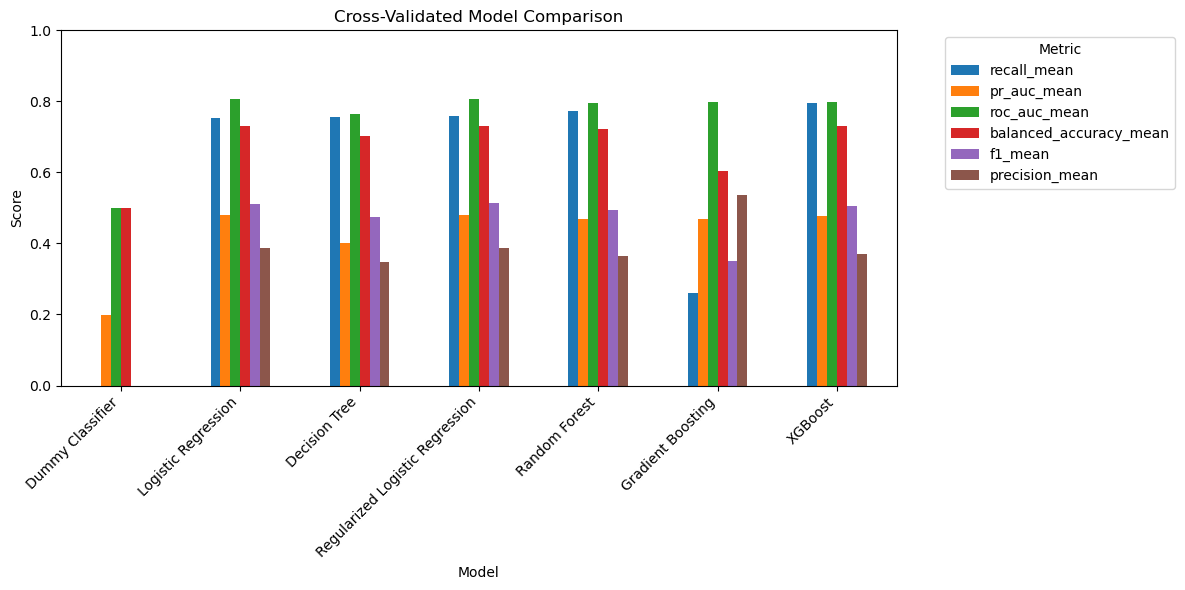

In [22]:
# Multiple KPI comparison

metrics_for_plot = [
    "recall_mean",
    "pr_auc_mean",
    "roc_auc_mean",
    "balanced_accuracy_mean",
    "f1_mean",
    "precision_mean"
]

plot_df.set_index("model")[metrics_for_plot].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cross-Validated Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
model_comp_multiple_kpi_path = modeling_dir / "model_comp_multiple_kpi.png"
plt.savefig(model_comp_multiple_kpi_path, dpi=300, bbox_inches="tight")
plt.show()

### Model Comparison Plots

Model comparison plots were used to visualize cross-validated performance across the candidate models. Since this project focuses on early diabetes risk screening, diabetes recall was treated as the primary KPI. PR-AUC, ROC-AUC, balanced accuracy, F1-score, precision, and accuracy were used as secondary metrics.

Accuracy was included for reference, but it was not used as the main model-selection metric because the dataset is imbalanced. A model can achieve high accuracy by predicting the majority class, non-diabetes, while still missing many diabetes cases.

The plots help show the tradeoff between models. XGBoost achieved the highest recall, while other models such as Regularized Logistic Regression showed competitive secondary metrics and better interpretability.

In [23]:
# Select final model using recall first, then secondary KPIs

recall_tolerance = 0.01
max_recall = model_comparison["recall_mean"].max()
candidate_models = model_comparison[
    model_comparison["recall_mean"] >= max_recall - recall_tolerance
].copy()

candidate_models_rounded = candidate_models.copy()
num_cols = candidate_models_rounded.select_dtypes(include=["float64"]).columns
candidate_models_rounded[num_cols] = candidate_models_rounded[num_cols].round(4)

candidate_models_rounded[display_cols].sort_values(
    by=["pr_auc_mean", "roc_auc_mean", "balanced_accuracy_mean", "f1_mean"],
    ascending=False
)

,model,model_group,tuning_type,recall_mean,pr_auc_mean,roc_auc_mean,balanced_accuracy_mean,f1_mean,precision_mean,accuracy_mean
6,XGBoost,advanced_model,RandomizedSearchCV_refit_recall,0.7953,0.4759,0.7993,0.7306,0.5041,0.369,0.6914


In [24]:
selected_row = candidate_models.sort_values(
    by=["pr_auc_mean", "roc_auc_mean", "balanced_accuracy_mean", "f1_mean"],
    ascending=False
).iloc[0]

final_model_name = selected_row["model"]

print("Selected final model:")
print(final_model_name)

print("\nSelected model CV metrics:")
print(selected_row[[
    "recall_mean",
    "pr_auc_mean",
    "roc_auc_mean",
    "balanced_accuracy_mean",
    "f1_mean",
    "precision_mean",
    "accuracy_mean"
]])

Selected final model:
XGBoost

Selected model CV metrics:
recall_mean               0.795316
pr_auc_mean               0.475874
roc_auc_mean              0.799347
balanced_accuracy_mean    0.730599
f1_mean                   0.504058
precision_mean            0.368982
accuracy_mean             0.691401
Name: 6, dtype: object


Models were compared using recall as the primary KPI because the goal of this project is early diabetes risk screening. After comparing recall, secondary KPIs such as PR-AUC, ROC-AUC, balanced accuracy, F1-score, precision, and interpretability were reviewed.

XGBoost achieved the highest recall, meaning it identified the largest proportion of diabetes cases. Compared with Regularized Logistic Regression, XGBoost improved recall by about 3.7 percentage points, while precision decreased by about 1.8 percentage points. Since recall is the primary KPI and the loss in precision was relatively small, XGBoost was selected as the final high-recall model. Although XGBoost had a lower accuracy than Regularized Logistic Regression, it achieved higher recall, which is the primary KPI for this diabetes screening project. The lower accuracy is likely due to XGBoost predicting more participants as diabetes, which increases true positives but also increases false positives. Since the dataset is imbalanced (Non-diabetes = 80% approx., Diabetes = 20% approx.), accuracy alone is not the best metric for model selection. Therefore, the decrease in accuracy was considered acceptable because XGBoost improved recall.

However, Regularized Logistic Regression remains a strong interpretable alternative because it performed slightly better on several secondary KPIs.

In [25]:
# Get the final estimator

if final_model_name in best_estimators:
    final_pipeline = best_estimators[final_model_name]
else:
    final_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", baseline_models[final_model_name])
    ])

    final_pipeline.fit(X_train, y_train)

print(final_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['RIDAGEYR', 'INDFMPIR',
                                                   'BMXBMI', 'BMXWAIST',
                                                   'PAD680', 'ALQ130', 'DBD895',
                                                   'DBD900', 'DBD905', 'DBD910',
                                                   'avg_systolic_bp',
                                                   'avg_diastolic_bp',
                                                   'pulse_pressure', 'age_bmi',
                                  

This code retrieves the final selected model pipeline. If the selected model is an advanced tuned model, the best tuned pipeline is taken from `best_estimators`. If the selected model is a baseline model, a new pipeline is created using the same preprocessing steps and then fitted on the full training data. The resulting `final_pipeline` is used for final test evaluation and model serialization.

In [26]:
# Tune threshold using training CV predictions only

def threshold_metrics(y_true, y_prob, thresholds):
    rows = []

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        rows.append({
            "threshold": threshold,
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
        })

    return pd.DataFrame(rows)

In [27]:
# Get cross-validated probabilities on training set only

y_train_prob_cv = cross_val_predict(
    final_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = threshold_metrics(
    y_true=y_train,
    y_prob=y_train_prob_cv,
    thresholds=thresholds
)

threshold_results.head()

,threshold,recall,precision,f1,balanced_accuracy
0,0.10,0.989011,0.223741,0.364927,0.573187
1,0.11,0.987637,0.229419,0.372346,0.586499
2,0.12,0.984890,0.233360,0.377319,0.595161
3,0.13,0.984203,0.237291,0.382388,0.603672
4,0.14,0.982830,0.241397,0.387595,0.612177


In [28]:
target_recall = 0.75

threshold_candidates = threshold_results[
    threshold_results["recall"] >= target_recall
].copy()

if len(threshold_candidates) > 0:
    selected_threshold_row = threshold_candidates.sort_values(
        by=["f1", "balanced_accuracy", "precision"],
        ascending=False
    ).iloc[0]
else:
    selected_threshold_row = threshold_results.sort_values(
        by=["recall", "f1"],
        ascending=False
    ).iloc[0]

selected_threshold = selected_threshold_row["threshold"]

print("Selected threshold:")
print(selected_threshold)

selected_threshold_row

Selected threshold:
0.5299999999999998


threshold            0.530000
recall               0.753434
precision            0.384642
f1                   0.509285
balanced_accuracy    0.728716
Name: 43, dtype: float64

### Threshold Selection Result

Threshold tuning was performed using cross-validated predicted probabilities from the training set. The target recall was set to 0.75 to maintain strong diabetes detection. Among thresholds with recall at least 0.75, the selected threshold was 0.53. At this threshold, the model achieved recall of 0.7534, precision of 0.3846, F1-score of 0.5093, and balanced accuracy of 0.7287.
This threshold keeps recall above the target level while maintaining reasonable precision and F1-score. Therefore, 0.53 was selected as the classification threshold for final test evaluation.

In [29]:
# Save the threshold result 

threshold_results_path = modeling_dir / f"threshold_tuning_{final_model_name.replace(' ', '_')}.csv"
threshold_results.round(4).to_csv(threshold_results_path, index=False)

In [30]:
# Fit final model on full training set

final_pipeline.fit(X_train, y_train)
print("Final model fitted on full training set:")
print(final_model_name)

Final model fitted on full training set:
XGBoost


In [31]:
# Evaluate once on final test set

y_test_prob = final_pipeline.predict_proba(X_test)[:, 1]

# Default threshold result
y_test_pred_default = (y_test_prob >= 0.50).astype(int)

# Tuned threshold result
y_test_pred_tuned = (y_test_prob >= selected_threshold).astype(int)

In [32]:
def evaluate_test_predictions(y_true, y_pred, y_prob, model_name, threshold):
    results = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob)
    }

    return results

In [33]:
final_test_results = pd.DataFrame([
    evaluate_test_predictions(
        y_true=y_test,
        y_pred=y_test_pred_default,
        y_prob=y_test_prob,
        model_name=final_model_name,
        threshold=0.50
    ),
    evaluate_test_predictions(
        y_true=y_test,
        y_pred=y_test_pred_tuned,
        y_prob=y_test_prob,
        model_name=final_model_name,
        threshold=selected_threshold
    )
])

final_test_results.round(4)

,model,threshold,accuracy,balanced_accuracy,recall,precision,f1,roc_auc,pr_auc
0,XGBoost,0.50,0.6957,0.7369,0.8049,0.3737,0.5105,0.7975,0.4513
1,XGBoost,0.53,0.7114,0.7291,0.7582,0.3828,0.5088,0.7975,0.4513


### Final Threshold Comparison

The XGBoost model was evaluated on the final holdout test set using both the default threshold of 0.50 and the tuned threshold of 0.53. Although the tuned threshold slightly improved precision and accuracy, the default threshold achieved higher recall, F1-score, and balanced accuracy.

Since recall is the primary KPI for this early diabetes screening project, the default threshold of 0.50 was preferred for the final model. At this threshold, the model achieved recall of 0.8049, meaning it identified about 80.5% of diabetes cases in the test set.

In [34]:
# Final test KPI result 

final_test_results = pd.DataFrame([
    evaluate_test_predictions(
        y_true=y_test,
        y_pred=y_test_pred_default,
        y_prob=y_test_prob,
        model_name=final_model_name,
        threshold=0.50
    )
])
final_test_results.round(4)    

,model,threshold,accuracy,balanced_accuracy,recall,precision,f1,roc_auc,pr_auc
0,XGBoost,0.5,0.6957,0.7369,0.8049,0.3737,0.5105,0.7975,0.4513


In [35]:
# Save the final test result 

final_test_results_path = final_dir / f"final_test_KPI_table_{final_model_name.replace(' ', '_')}.csv"
final_test_results.round(4).to_csv(final_test_results_path, index=False)

In [36]:
# Create prediction table for final XGBoost model

prediction_table = X_test.copy()

prediction_table["true_label"] = y_test.values
prediction_table["predicted_probability"] = y_test_prob
prediction_table["predicted_probability (%)"] = (
    prediction_table["predicted_probability"] * 100
).round(2)

prediction_table["prediction"] = np.where(
    prediction_table["predicted_probability"] >= 0.50,
    "Predicted High Risk",
    "Predicted Lower Risk"
)

prediction_table["true_label"] = np.where(
    prediction_table["true_label"] == 1,
    "Diabetes",
    "Non-Diabetes"
)

prediction_table.head()

,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPQ020,BPQ080,SMQ020,...,fair_poor_diet,frequent_fast_food,age_bmi,age_waist,age_systolic_bp,metabolic_risk_score,true_label,predicted_probability,predicted_probability (%),prediction
1559,57.0,1.0,1.0,1.0,1.39,25.9,91.7,2.0,2.0,2.0,...,0.0,0.0,1476.3,5226.9,6650.000000,0.0,Diabetes,0.476429,47.639999,Predicted Lower Risk
5966,75.0,2.0,3.0,3.0,2.96,30.7,111.4,1.0,1.0,1.0,...,0.0,0.0,2302.5,8355.0,9275.000000,3.0,Non-Diabetes,0.736432,73.639999,Predicted High Risk
1446,31.0,1.0,6.0,5.0,NaN,27.4,97.6,2.0,2.0,2.0,...,0.0,0.0,849.4,3025.6,3420.333333,0.0,Non-Diabetes,0.086015,8.600000,Predicted Lower Risk
5789,33.0,2.0,3.0,5.0,5.00,23.5,86.6,2.0,2.0,1.0,...,0.0,0.0,775.5,2857.8,3652.000000,1.0,Non-Diabetes,0.071165,7.120000,Predicted Lower Risk
7893,48.0,1.0,6.0,4.0,3.40,25.5,92.5,1.0,1.0,2.0,...,0.0,1.0,1224.0,4440.0,6928.000000,1.0,Non-Diabetes,0.489766,48.980000,Predicted Lower Risk


In [37]:
# Show only selected useful columns

selected_display_cols = [
    "prediction",
    "predicted_probability(%)",
    "true_label",
    "RIDAGEYR",
    "BMXBMI",
    "BMXWAIST",
    "avg_systolic_bp",
    "avg_diastolic_bp",
    "pulse_pressure",
    "metabolic_risk_score",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2"
]

selected_display_cols = [
    col for col in selected_display_cols
    if col in prediction_table.columns
]

prediction_table_display = prediction_table[selected_display_cols].copy()

prediction_table_display.head(15)

,prediction,true_label,RIDAGEYR,BMXBMI,BMXWAIST,avg_systolic_bp,avg_diastolic_bp,pulse_pressure,metabolic_risk_score,RIAGENDR,RIDRETH3,DMDEDUC2
1559,Predicted Lower Risk,Diabetes,57.0,25.9,91.7,116.666667,64.333333,52.333333,0.0,1.0,1.0,1.0
5966,Predicted High Risk,Non-Diabetes,75.0,30.7,111.4,123.666667,60.333333,63.333333,3.0,2.0,3.0,3.0
1446,Predicted Lower Risk,Non-Diabetes,31.0,27.4,97.6,110.333333,74.000000,36.333333,0.0,1.0,6.0,5.0
5789,Predicted Lower Risk,Non-Diabetes,33.0,23.5,86.6,110.666667,65.333333,45.333333,1.0,2.0,3.0,5.0
7893,Predicted Lower Risk,Non-Diabetes,48.0,25.5,92.5,144.333333,89.000000,55.333333,1.0,1.0,6.0,4.0
3900,Predicted Lower Risk,Non-Diabetes,76.0,24.7,89.4,165.666667,89.000000,76.666667,3.0,2.0,3.0,4.0
8371,Predicted High Risk,Non-Diabetes,71.0,50.6,140.4,122.333333,77.666667,44.666667,3.0,2.0,4.0,3.0
6466,Predicted High Risk,Non-Diabetes,48.0,39.4,132.3,115.333333,81.333333,34.000000,3.0,1.0,2.0,3.0
4911,Predicted Lower Risk,Non-Diabetes,31.0,19.9,77.4,100.333333,63.000000,37.333333,0.0,2.0,3.0,5.0
2483,Predicted Lower Risk,Non-Diabetes,38.0,28.8,92.8,117.000000,75.000000,42.000000,0.0,1.0,1.0,1.0


### Prediction Probability Table 

A prediction table was created to show example outputs from the final XGBoost screening model. For each participant in the holdout test set, the table includes the predicted diabetes-risk category, predicted probability, true label, and selected interpretable features.

The prediction should not be interpreted as a clinical diagnosis. Instead, a “Predicted High Risk” result means that the participant was flagged by the model as potentially higher risk of diabetes and may need further clinical evaluation. This is consistent with the project goal of early diabetes risk screening.

In [65]:
# Save the table 

prediction_table_display.to_csv(
    "../results/final/final_model_prediction.csv",
    index=False
)

In [39]:
# Final selected threshold based on test comparison
final_threshold = 0.50
y_test_pred_final = y_test_pred_default

#Classification report 

classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_test_pred_final,
        output_dict=True,
        zero_division=0
    )
).T

classification_report_df.round(4)

,precision,recall,f1-score,support
0,0.9332,0.6689,0.7793,1483.0000
1,0.3737,0.8049,0.5105,364.0000
accuracy,0.6957,0.6957,0.6957,0.6957
macro avg,0.6535,0.7369,0.6449,1847.0000
weighted avg,0.8229,0.6957,0.7263,1847.0000


### Classification Report Interpretation

The final XGBoost model was evaluated on the holdout test set using the selected final threshold of 0.50. Class `0` represents non-diabetes participants, and class `1` represents diabetes participants.

For the diabetes class, the model achieved recall of 0.80. This means the model correctly identified about 80% of actual diabetes cases in the test set. Since this project focuses on early diabetes risk screening, this is an important result because recall is the primary KPI.

The precision for the diabetes class was 0.37. This means that among participants predicted as diabetes, about 37% were actually diabetes cases. The lower precision indicates that the model produces some false positives, but this tradeoff may be acceptable in a screening setting where missing diabetes cases is more costly than flagging some non-diabetes participants for follow-up.

For the non-diabetes class, the model achieved high precision of 0.93 but lower recall of 0.67. This means the model is reliable when it predicts non-diabetes, but it also classifies some non-diabetes participants as diabetes in order to increase diabetes detection.

Overall, the model achieved an accuracy of 0.70 and a diabetes-class F1-score of 0.51. Although accuracy is moderate, it is not the main metric for this imbalanced screening problem. The main strength of the model is its high diabetes recall, which aligns with the goal of early diabetes risk screening.

In [40]:
classification_report_df.to_csv(
    final_dir / "final_classification_report.csv"
)

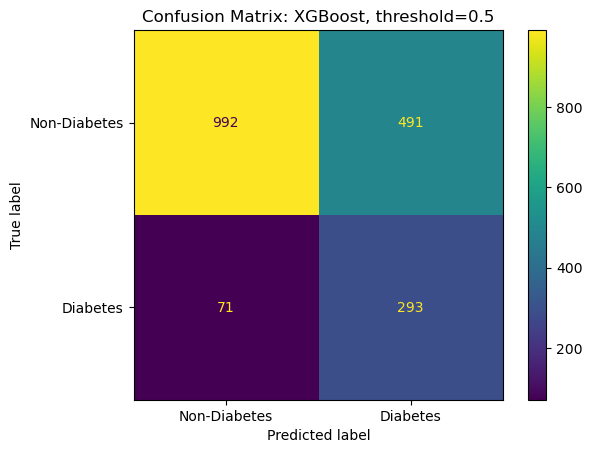

In [41]:
# Confusion matrix 

cm = confusion_matrix(y_test, y_test_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetes", "Diabetes"]
)

disp.plot()
plt.title(f"Confusion Matrix: {final_model_name}, threshold={final_threshold}")
confusion_matrix_path = final_dir / "final_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows the final XGBoost model performance on the holdout test set using threshold 0.50.

The model correctly classified 992 non-diabetes participants and 293 diabetes participants. It missed 71 diabetes cases, which are false negatives, and incorrectly flagged 491 non-diabetes participants as diabetes-risk, which are false positives.

For the diabetes class, the model correctly identified 293 out of 364 actual diabetes cases. This gives a diabetes recall of approximately 0.805, meaning the model detected about 80.5% of diabetes cases in the test set. Since recall is the primary KPI for this early diabetes screening project, this is an important strength of the model.

However, the model also produced 491 false positives. This means many non-diabetes participants were flagged as diabetes-risk. Therefore, the model should not be interpreted as a diagnostic tool. Instead, it should be viewed as a screening model that identifies participants who may need further clinical evaluation.

Overall, the confusion matrix shows that the XGBoost model is useful for high-recall diabetes screening, but its false-positive rate is a limitation.

In [42]:
# Create error analysis dataframe
error_df = X_test.copy()

error_df["y_true"] = y_test.to_numpy()
error_df["y_pred"] = y_test_pred_final
error_df["y_prob"] = y_test_prob

error_df["error_type"] = np.select(
    [
        (error_df["y_true"] == 0) & (error_df["y_pred"] == 0),
        (error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
        (error_df["y_true"] == 1) & (error_df["y_pred"] == 0),
        (error_df["y_true"] == 1) & (error_df["y_pred"] == 1)
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    default="Unknown"
)

error_df["error_type"].value_counts()

error_type
True Negative     992
False Positive    491
True Positive     293
False Negative     71
Name: count, dtype: int64

In [43]:
error_df.to_csv(
    final_dir / "error_analysis.csv"
)

In [44]:
def subgroup_error_summary(df, group_col):
    rows = []

    for group_value, group_df in df.groupby(group_col, dropna=False):
        n = len(group_df)

        tp = ((group_df["y_true"] == 1) & (group_df["y_pred"] == 1)).sum()
        fn = ((group_df["y_true"] == 1) & (group_df["y_pred"] == 0)).sum()
        fp = ((group_df["y_true"] == 0) & (group_df["y_pred"] == 1)).sum()
        tn = ((group_df["y_true"] == 0) & (group_df["y_pred"] == 0)).sum()

        diabetes_cases = tp + fn
        non_diabetes_cases = tn + fp

        recall = tp / diabetes_cases if diabetes_cases > 0 else np.nan
        false_negative_rate = fn / diabetes_cases if diabetes_cases > 0 else np.nan
        false_positive_rate = fp / non_diabetes_cases if non_diabetes_cases > 0 else np.nan
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

        rows.append({
            "subgroup_variable": group_col,
            "subgroup": group_value,
            "n": n,
            "diabetes_cases": diabetes_cases,
            "non_diabetes_cases": non_diabetes_cases,
            "true_positive": tp,
            "false_negative": fn,
            "false_positive": fp,
            "true_negative": tn,
            "recall": recall,
            "false_negative_rate": false_negative_rate,
            "false_positive_rate": false_positive_rate,
            "precision": precision
        })

    return pd.DataFrame(rows)

In [45]:
subgroup_cols = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2"
]

subgroup_cols = [col for col in subgroup_cols if col in error_df.columns]

subgroup_error_results = pd.concat(
    [subgroup_error_summary(error_df, col) for col in subgroup_cols],
    ignore_index=True
)

subgroup_error_results.round(4)

,subgroup_variable,subgroup,n,diabetes_cases,non_diabetes_cases,true_positive,false_negative,false_positive,true_negative,recall,false_negative_rate,false_positive_rate,precision
0,RIAGENDR,1.0,893,196,697,157,39,241,456,0.8010,0.1990,0.3458,0.3945
1,RIAGENDR,2.0,954,168,786,136,32,250,536,0.8095,0.1905,0.3181,0.3523
2,RIDRETH3,1.0,210,50,160,39,11,50,110,0.7800,0.2200,0.3125,0.4382
3,RIDRETH3,2.0,179,43,136,37,6,52,84,0.8605,0.1395,0.3824,0.4157
4,RIDRETH3,3.0,679,113,566,93,20,196,370,0.8230,0.1770,0.3463,0.3218
5,RIDRETH3,4.0,466,98,368,82,16,139,229,0.8367,0.1633,0.3777,0.3710
6,RIDRETH3,6.0,217,46,171,30,16,33,138,0.6522,0.3478,0.1930,0.4762
7,RIDRETH3,7.0,96,14,82,12,2,21,61,0.8571,0.1429,0.2561,0.3636
8,DMDEDUC2,1.0,157,52,105,45,7,62,43,0.8654,0.1346,0.5905,0.4206
9,DMDEDUC2,2.0,206,49,157,42,7,56,101,0.8571,0.1429,0.3567,0.4286


In [46]:
subgroup_error_results.round(4).to_csv(
    final_dir / "subgroup_error_analysis.csv"
)

### Handling Missing Subgroup Values

The subgroup analysis was performed using the original observed subgroup variables from the test set. One row had a missing value for `DMDEDUC2`, representing only one participant. Because this missing subgroup contained only one participant and no diabetes cases, recall and false negative rate were undefined.

Therefore, the missing subgroup row was excluded from the main subgroup interpretation. This exclusion does not affect the main subgroup conclusions because the row contained only one participant. The model itself still used imputation internally through the preprocessing pipeline for prediction.

In [47]:
subgroup_error_results_clean = subgroup_error_results.dropna(
    subset=["subgroup"]
).copy()
subgroup_error_results_clean.round(4)

,subgroup_variable,subgroup,n,diabetes_cases,non_diabetes_cases,true_positive,false_negative,false_positive,true_negative,recall,false_negative_rate,false_positive_rate,precision
0,RIAGENDR,1.0,893,196,697,157,39,241,456,0.8010,0.1990,0.3458,0.3945
1,RIAGENDR,2.0,954,168,786,136,32,250,536,0.8095,0.1905,0.3181,0.3523
2,RIDRETH3,1.0,210,50,160,39,11,50,110,0.7800,0.2200,0.3125,0.4382
3,RIDRETH3,2.0,179,43,136,37,6,52,84,0.8605,0.1395,0.3824,0.4157
4,RIDRETH3,3.0,679,113,566,93,20,196,370,0.8230,0.1770,0.3463,0.3218
5,RIDRETH3,4.0,466,98,368,82,16,139,229,0.8367,0.1633,0.3777,0.3710
6,RIDRETH3,6.0,217,46,171,30,16,33,138,0.6522,0.3478,0.1930,0.4762
7,RIDRETH3,7.0,96,14,82,12,2,21,61,0.8571,0.1429,0.2561,0.3636
8,DMDEDUC2,1.0,157,52,105,45,7,62,43,0.8654,0.1346,0.5905,0.4206
9,DMDEDUC2,2.0,206,49,157,42,7,56,101,0.8571,0.1429,0.3567,0.4286


### Subgroup Error Analysis

Subgroup error analysis was performed to examine whether the final XGBoost model errors were randomly distributed or concentrated in specific demographic groups. The analysis was conducted across gender (`RIAGENDR`), race/ethnicity (`RIDRETH3`), and education level (`DMDEDUC2`).

For gender, the model showed similar recall across groups. The recall was 0.8010 for `RIAGENDR = 1.0` and 0.8095 for `RIAGENDR = 2.0`, suggesting that diabetes detection was relatively consistent across gender groups.

For race/ethnicity, recall varied across subgroups. Most groups had recall between approximately 0.78 and 0.86, but `RIDRETH3 = 6.0` had a noticeably lower recall of 0.6522 and a higher false negative rate of 0.3478. This suggests that the model missed more diabetes cases in this subgroup. However, this result should be interpreted carefully because this subgroup had only 46 diabetes cases in the test set.

For education level, recall was high for `DMDEDUC2 = 1.0`, `2.0`, and `3.0`, but lower for `DMDEDUC2 = 4.0` and `5.0`. In particular, `DMDEDUC2 = 5.0` had recall of 0.7089, suggesting weaker diabetes detection for this subgroup. The false positive rate was also high for `DMDEDUC2 = 1.0`, meaning many non-diabetes participants in this group were flagged as diabetes-risk.

Overall, the subgroup analysis shows that the model performs reasonably well across several groups, but errors are not completely random. Some subgroups show higher false negative rates or higher false positive rates. Future work should investigate these subgroup differences further and consider threshold tuning, calibration, or additional feature engineering to improve subgroup robustness.

In [48]:
# Check false negatives for specific subgroups

focus_groups = [
    ("RIDRETH3", 6.0),
    ("DMDEDUC2", 5.0)
]

for group_col, group_value in focus_groups:
    sub = error_df[
        (error_df[group_col] == group_value) &
        (error_df["y_true"] == 1)
    ].copy()

    print("=" * 60)
    print(f"{group_col} = {group_value}")
    print("Number of diabetes cases:", len(sub))
    print(sub["error_type"].value_counts())
    print("\nPredicted probability summary:")
    print(sub["y_prob"].describe())

RIDRETH3 = 6.0
Number of diabetes cases: 46
error_type
True Positive     30
False Negative    16
Name: count, dtype: int64

Predicted probability summary:
count    46.000000
mean      0.549195
std       0.160509
min       0.135093
25%       0.429718
50%       0.574228
75%       0.674873
max       0.821154
Name: y_prob, dtype: float64
DMDEDUC2 = 5.0
Number of diabetes cases: 79
error_type
True Positive     56
False Negative    23
Name: count, dtype: int64

Predicted probability summary:
count    79.000000
mean      0.570471
std       0.161619
min       0.135093
25%       0.462571
50%       0.596176
75%       0.693567
max       0.804635
Name: y_prob, dtype: float64


### False Negative Review for Lower-Recall Subgroups

A focused review was conducted for subgroups with lower diabetes recall: `RIDRETH3 = 6.0` and `DMDEDUC2 = 5.0`.

For `RIDRETH3 = 6.0`, there were 46 actual diabetes cases in the test set. The model correctly identified 30 cases and missed 16 cases, giving a recall of 0.6522. The predicted probability distribution had a median of 0.5742, but the first quartile was 0.4297, indicating that some diabetes cases were assigned probabilities below the 0.50 threshold and became false negatives.

For `DMDEDUC2 = 5.0`, there were 79 actual diabetes cases. The model correctly identified 56 cases and missed 23 cases, giving a recall of 0.7089. The median predicted probability was 0.5962, while the first quartile was 0.4626. This also suggests that some missed diabetes cases were close to the classification threshold.

These results suggest that the model did not completely fail for these subgroups, but some diabetes cases were assigned probabilities near or below the threshold. Future iterations may investigate whether additional clinical interaction features, missingness indicators, or subgroup-aware threshold analysis can improve recall for these groups.

In [49]:
#Compare true positives vs false negatives

clinical_features = [
    "RIDAGEYR",
    "BMXBMI",
    "BMXWAIST",
    "avg_systolic_bp",
    "avg_diastolic_bp",
    "pulse_pressure",
    "age_bmi",
    "age_waist",
    "metabolic_risk_score",
    "INDFMPIR"
]

clinical_features = [col for col in clinical_features if col in error_df.columns]

for group_col, group_value in focus_groups:
    sub = error_df[
        (error_df[group_col] == group_value) &
        (error_df["y_true"] == 1)
    ].copy()

    sub["missed_diabetes"] = np.where(sub["y_pred"] == 0, "False Negative", "True Positive")

    print("=" * 60)
    print(f"{group_col} = {group_value}")
    
    display(
        sub.groupby("missed_diabetes")[clinical_features + ["y_prob"]]
        .mean()
        .round(3)
    )

RIDRETH3 = 6.0


,RIDAGEYR,BMXBMI,BMXWAIST,avg_systolic_bp,avg_diastolic_bp,pulse_pressure,age_bmi,age_waist,metabolic_risk_score,INDFMPIR,y_prob
missed_diabetes,,,,,,,,,,,
False Negative,56.688,23.600,89.913,121.244,73.733,47.511,1298.200,4954.880,0.812,4.194,0.369
True Positive,64.067,28.061,98.850,127.400,71.520,55.880,1768.364,6281.865,1.700,2.657,0.645


DMDEDUC2 = 5.0


,RIDAGEYR,BMXBMI,BMXWAIST,avg_systolic_bp,avg_diastolic_bp,pulse_pressure,age_bmi,age_waist,metabolic_risk_score,INDFMPIR,y_prob
missed_diabetes,,,,,,,,,,,
False Negative,53.217,26.130,96.405,120.850,76.317,44.533,1352.895,5053.900,1.609,4.251,0.359
True Positive,64.357,33.208,112.453,126.184,73.642,52.542,2100.431,7097.838,2.179,3.454,0.657


### Compare true positives vs false negatives for Lower-Recall Subgroups

A focused error analysis was performed for the lower-recall subgroups `RIDRETH3 = 6.0` and `DMDEDUC2 = 5.0`. Within each subgroup, actual diabetes cases were separated into false negatives and true positives to compare their average clinical characteristics.

For both subgroups, the false negative cases had lower average age, BMI, waist circumference, pulse pressure, age-BMI interaction, age-waist interaction, and metabolic risk score than the true positive cases. This suggests that the model was more successful at detecting diabetes cases when participants had stronger visible risk patterns, such as older age, higher body-size measures, and higher metabolic risk score.

In contrast, the missed diabetes cases appeared less clinically obvious based on the available predictors. Their predicted probabilities were also much lower than the true positive cases, indicating that the model assigned them lower diabetes-risk scores.

This result suggests that the lower subgroup recall may not be caused by a simple coding or feature-selection error. Instead, it may reflect a limitation of the available predictors: some diabetes cases may not show strong risk signals in age, BMI, waist circumference, blood pressure, or the engineered risk features.

Future iterations could revisit feature engineering by adding additional clinically meaningful interaction features, reviewing missingness patterns, and investigating whether other non-leakage predictors can help identify less obvious diabetes cases.

In [50]:
# Check missingness by subgroup

for group_col, group_value in focus_groups:
    sub = X_test[X_test[group_col] == group_value].copy()

    missing_summary = sub.isna().mean().sort_values(ascending=False).head(15)

    print("=" * 60)
    print(f"Top missing features for {group_col} = {group_value}")
    display(missing_summary.round(3))

Top missing features for RIDRETH3 = 6.0


ALQ130                  0.548
ALQ121                  0.415
DBD900                  0.346
ALQ111                  0.217
ever_regular_alcohol    0.217
avg_diastolic_bp        0.203
avg_systolic_bp         0.203
high_bp_exam            0.203
pulse_pressure          0.203
age_systolic_bp         0.203
INDFMPIR                0.161
BMXWAIST                0.134
high_waist              0.134
age_waist               0.134
obese                   0.092
dtype: float64

Top missing features for DMDEDUC2 = 5.0


ALQ130                  0.380
ALQ121                  0.220
DBD900                  0.176
age_systolic_bp         0.154
pulse_pressure          0.154
avg_diastolic_bp        0.154
avg_systolic_bp         0.154
high_bp_exam            0.154
ever_regular_alcohol    0.135
ALQ111                  0.135
age_waist               0.128
BMXWAIST                0.128
high_waist              0.128
INDFMPIR                0.111
obese                   0.096
dtype: float64

### Missingness Review for Lower-Recall Subgroups

A missingness review was performed for the lower-recall subgroups `RIDRETH3 = 6.0` and `DMDEDUC2 = 5.0`. The results showed that several lifestyle, alcohol, diet, blood-pressure, and waist-related variables had noticeable missingness in these groups.

For `RIDRETH3 = 6.0`, alcohol-related variables such as `ALQ130` and `ALQ121` had high missingness, and blood-pressure-related features such as `avg_systolic_bp`, `avg_diastolic_bp`, `high_bp_exam`, `pulse_pressure`, and `age_systolic_bp` were missing for about 20.3% of participants. Waist-related variables also had missingness around 13.4%.

For `DMDEDUC2 = 5.0`, alcohol-related variables were also among the most missing features, and blood-pressure-related features were missing for about 15.4% of participants. Waist-related variables were missing for about 12.8%.

This suggests that lower subgroup recall may be partly related to missing information in clinically relevant predictors. Although the preprocessing pipeline imputes missing values, imputation may not fully recover the information lost from missing clinical or lifestyle measurements.

Future modeling iterations could consider adding missingness indicator features for important predictors, reviewing whether highly missing lifestyle variables should be retained, and checking whether improved feature engineering can help reduce subgroup performance differences.

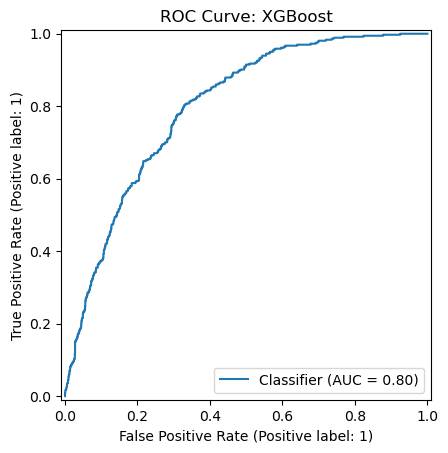

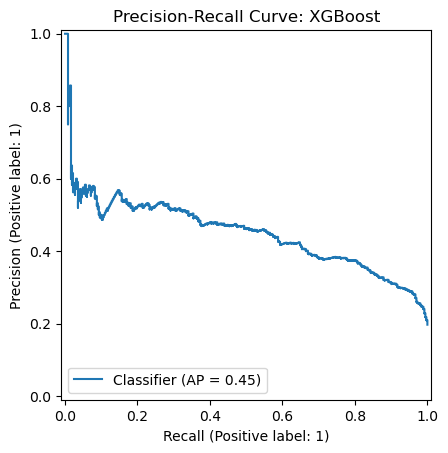

In [51]:
# ROC and PR curves

RocCurveDisplay.from_predictions(y_test, y_test_prob)
plt.title(f"ROC Curve: {final_model_name}")
ROC_path = final_dir / "final_roc_curve.png"
plt.savefig(ROC_path, dpi=300, bbox_inches="tight")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_test_prob)
plt.title(f"Precision-Recall Curve: {final_model_name}")
precision_recall_path = final_dir / "final_precision_recall_curve.png"
plt.savefig(precision_recall_path, dpi=300, bbox_inches="tight")
plt.show()

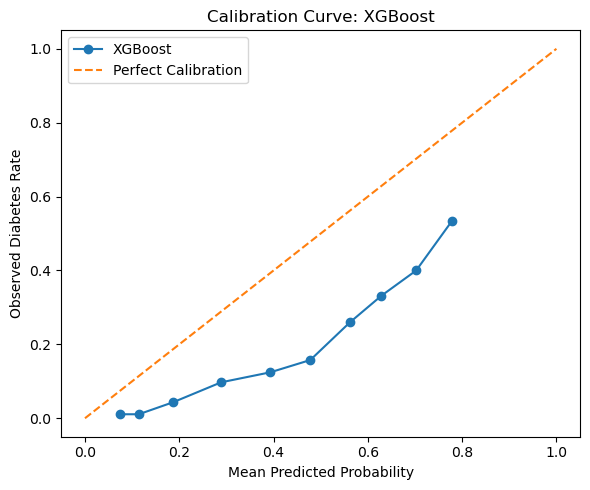

Brier score: 0.1875


In [52]:
# Compute calibration curve
prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_prob,
    n_bins=10,
    strategy="quantile"
)

# Compute Brier score
brier = brier_score_loss(y_test, y_test_prob)

# Plot calibration curve
plt.figure(figsize=(6, 5))

plt.plot(prob_pred, prob_true, marker="o", label=final_model_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.title(f"Calibration Curve: {final_model_name}")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Diabetes Rate")
plt.legend()
plt.tight_layout()

# Save figure
calibration_path = final_dir / "final_calibration_curve.png"
plt.savefig(calibration_path, dpi=300, bbox_inches="tight")

plt.show()
print("Brier score:", round(brier, 4))

### Calibration Curve Interpretation

The calibration curve compares the model's predicted diabetes-risk probabilities with the observed diabetes rate. The final XGBoost model's calibration curve is below the perfect calibration line for most probability ranges. This indicates that the model tends to overestimate diabetes-risk probabilities.

Therefore, the predicted probabilities should not be interpreted as exact clinical risk probabilities. Instead, they should be interpreted as relative screening scores. A higher predicted probability means the participant is more likely to be flagged as higher diabetes risk, but it does not represent a confirmed diagnosis. That means, the participant is predicted as higher diabetes-risk and may need follow-up evaluation.

The Brier score was 0.1875, indicating that the probability estimates are not perfectly calibrated. This is a limitation of the final model and suggests that probability calibration could be considered in future work.

In [53]:
# Interpretability outputs
# Get transformed feature names

def get_transformed_feature_names(fitted_pipeline, numeric_features, categorical_features):
    preprocessor = fitted_pipeline.named_steps["preprocessor"]

    try:
        feature_names = preprocessor.get_feature_names_out()
        feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]
        return feature_names

    except Exception:
        feature_names = []

        feature_names.extend(numeric_features)

        cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
        feature_names.extend(cat_names)

        return feature_names

In [54]:
feature_names = get_transformed_feature_names(
    fitted_pipeline=final_pipeline,
    numeric_features=numeric_features,
    categorical_features=categorical_features
)

print("Number of transformed features:", len(feature_names))

Number of transformed features: 78


### Transformed Feature Names

After preprocessing, the original feature set changes because numeric features are imputed and scaled, while categorical features are one-hot encoded into multiple binary columns. Therefore, transformed feature names were extracted from the fitted preprocessing pipeline so that model interpretability outputs, such as feature importance or coefficients, can be matched to the correct variables.

,feature,importance
13,age_bmi,0.129864
31,BPQ020_2.0,0.079935
14,age_waist,0.077451
30,BPQ020_1.0,0.074842
0,RIDAGEYR,0.073174
32,BPQ080_1.0,0.029714
33,BPQ080_2.0,0.028920
3,BMXWAIST,0.026705
45,PAQ650_2.0,0.025857
22,ALQ121_3.0,0.023741


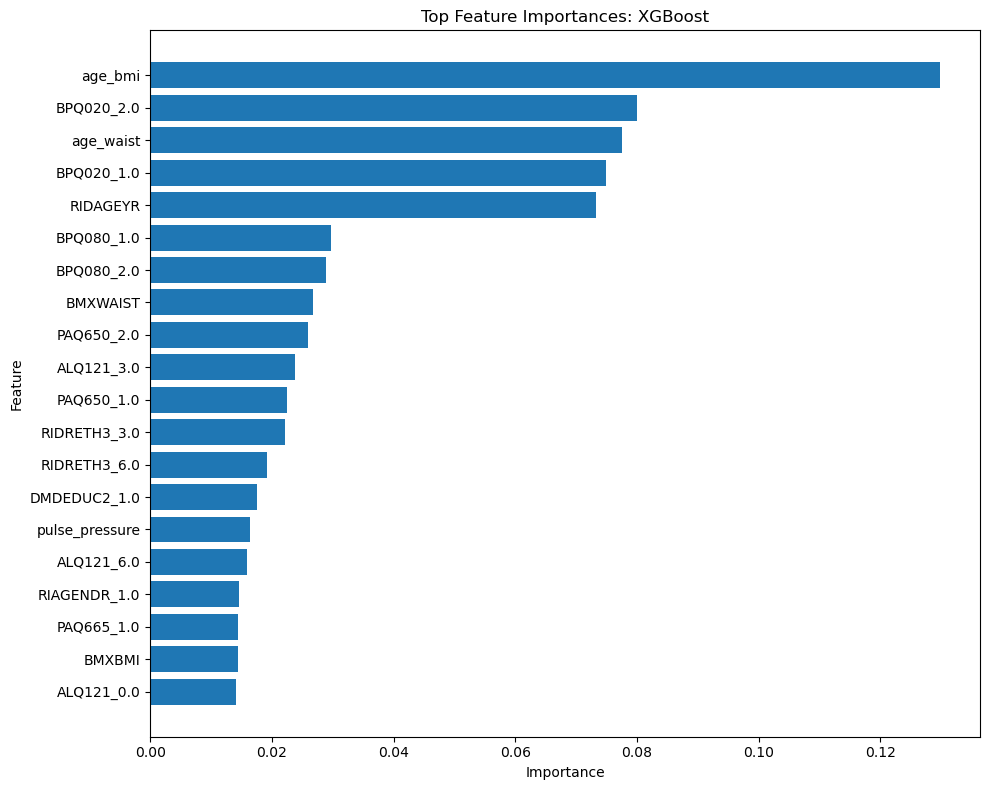

In [55]:
# Save coefficients and feature importances

final_model = final_pipeline.named_steps["model"]

# Coefficients for linear models such as Logistic Regression
if hasattr(final_model, "coef_"):
    coef_table = pd.DataFrame({
        "feature": feature_names,
        "coefficient": final_model.coef_[0]
    })

    coef_table["abs_coefficient"] = coef_table["coefficient"].abs()

    coef_table = coef_table.sort_values(
        "abs_coefficient",
        ascending=False
    )

    coef_path = interpretability_dir / f"{final_model_name.replace(' ', '_')}_coefficients.csv"
    coef_table.to_csv(coef_path, index=False)

    display(coef_table.head(20))
    top_coef = coef_table.head(20).sort_values("coefficient")

    plt.figure(figsize=(10, 8))
    plt.barh(top_coef["feature"], top_coef["coefficient"])
    plt.title(f"Top Logistic Regression Coefficients: {final_model_name}")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


# Feature importances for tree-based models such as Random Forest, Gradient Boosting, and XGBoost
elif hasattr(final_model, "feature_importances_"):
    importance_table = pd.DataFrame({
        "feature": feature_names,
        "importance": final_model.feature_importances_
    })

    importance_table = importance_table.sort_values(
        "importance",
        ascending=False
    )

    importance_path = interpretability_dir / f"{final_model_name.replace(' ', '_')}_feature_importance.csv"
    importance_table.to_csv(importance_path, index=False)

    display(importance_table.head(20))
    top_importance = importance_table.head(20).sort_values("importance")

    plt.figure(figsize=(10, 8))
    plt.barh(top_importance["feature"], top_importance["importance"])
    plt.title(f"Top Feature Importances: {final_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    print("This model does not provide coefficients or feature_importances_.")

In [56]:
!pip install shap

In [57]:
import shap

In [58]:
# Prepare transformed data for SHAP

preprocessor = final_pipeline.named_steps["preprocessor"]
xgb_model = final_pipeline.named_steps["model"]

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Convert sparse matrix to dense if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

print("Transformed training shape:", X_train_transformed.shape)
print("Transformed test shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

Transformed training shape: (7385, 78)
Transformed test shape: (1847, 78)
Number of feature names: 78


In [59]:
# Create transformed DataFrames

X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

X_test_transformed_df.head()

,RIDAGEYR,INDFMPIR,BMXBMI,BMXWAIST,PAD680,ALQ130,DBD895,DBD900,DBD905,DBD910,...,high_bp_exam_0.0,high_bp_exam_1.0,high_waist_0.0,high_waist_1.0,obese_0.0,obese_1.0,physically_active_0.0,physically_active_1.0,smoking_history_0.0,smoking_history_1.0
0,0.339176,-0.758185,-0.562694,-0.575660,-1.544113,-0.188117,-0.031553,-0.025186,-0.389991,-0.037077,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,1.356634,0.285193,0.099908,0.657539,-0.162546,-0.188117,-0.022619,-0.025186,-0.389991,-0.037077,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
2,-1.130486,-0.219882,-0.355631,-0.206326,-0.458596,-0.188117,-0.031553,-0.040651,-0.389991,-0.037077,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,-1.017435,1.640920,-0.893996,-0.894915,1.317704,-0.188117,-0.022619,-0.009721,-0.389991,-0.037077,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,-0.169553,0.577605,-0.617911,-0.525581,-1.050696,-0.188117,-0.004752,0.036674,0.571063,0.008454,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [60]:
sample_size = min(500, X_test_transformed_df.shape[0])

X_shap_sample = X_test_transformed_df.sample(
    n=sample_size,
    random_state=42
)

print("SHAP sample shape:", X_shap_sample.shape)

SHAP sample shape: (500, 78)


In [61]:
# Compute SHAP values

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap_sample)
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (500, 78)


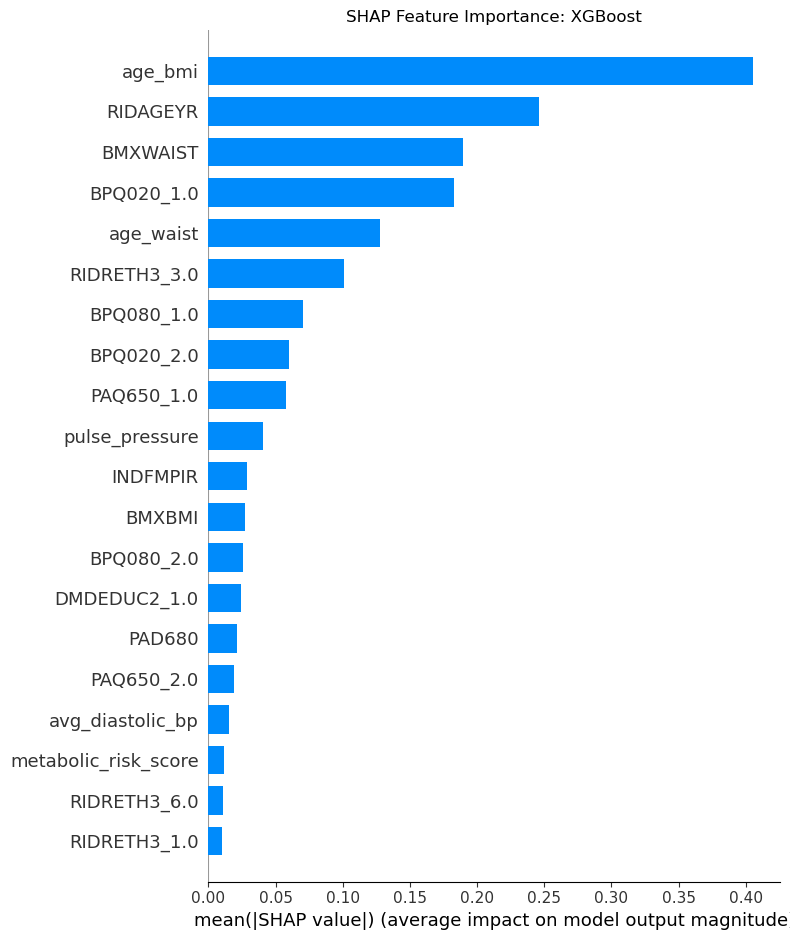

Saved: D:\Erdos\Data Science Bootcamp\summer26-diabetes-risk\early_diabetes_screening\results\interpretability\shap_summary_bar_xgboost.png


In [62]:
# SHAP summary bar plot

plt.figure()

shap.summary_plot(
    shap_values,
    X_shap_sample,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance: XGBoost")
plt.tight_layout()

shap_bar_path = interpretability_dir / "shap_summary_bar_xgboost.png"
plt.savefig(shap_bar_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", shap_bar_path)

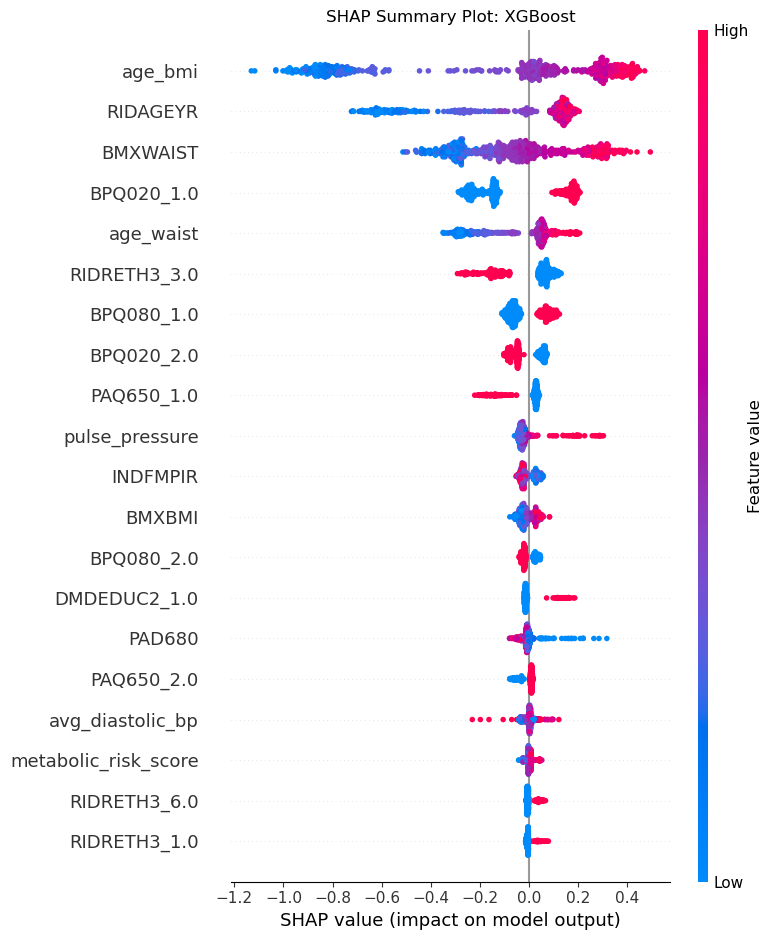

Saved: D:\Erdos\Data Science Bootcamp\summer26-diabetes-risk\early_diabetes_screening\results\interpretability\shap_summary_beeswarm_xgboost.png


In [83]:
# SHAP beeswarm plot

plt.figure()

shap.summary_plot(
    shap_values,
    X_shap_sample,
    show=False
)

plt.title("SHAP Summary Plot: XGBoost")
plt.tight_layout()

shap_summary_path = interpretability_dir / "shap_summary_beeswarm_xgboost.png"
plt.savefig(shap_summary_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", shap_summary_path)

### SHAP Summary Plot Interpretation

The SHAP summary plot was used to interpret the final XGBoost model. The features are ordered by their overall importance, with the most influential features appearing at the top. Positive SHAP values push the prediction toward the diabetes-risk class, while negative SHAP values push the prediction toward the non-diabetes class. The color represents the feature value, where red indicates a high value and blue indicates a low value.

The most influential features were `age_bmi`, `RIDAGEYR`, `BMXWAIST`, `BPQ020_1.0`, `age_waist`, `RIDRETH3_3.0`, `BPQ080_1.0`, `BPQ020_2.0`, `PAQ650_1.0`, and `pulse_pressure`.

The plot shows that higher values of `age_bmi`, `RIDAGEYR`, `BMXWAIST`, and `age_waist` generally pushed predictions toward higher diabetes risk. This is clinically reasonable because older age, higher BMI, and larger waist circumference are associated with increased diabetes risk.

Blood-pressure-related variables also had important effects. For example, `BPQ020_1.0` tended to push predictions toward diabetes risk, while `BPQ020_2.0` tended to push predictions in the opposite direction. This suggests that self-reported high blood pressure status was important for the XGBoost model.

Some one-hot encoded categorical features, such as `RIDRETH3_3.0`, `BPQ080_1.0`, `PAQ650_1.0`, `DMDEDUC2_1.0`, and `RIDRETH3_6.0`, should be interpreted carefully. For these variables, a high value means that the participant belongs to that category, while a low value means that the participant does not belong to that category. Therefore, their SHAP values represent the model effect of being in that category compared with other categories.

Overall, the SHAP plot supports the model interpretation by showing that age, BMI-related interaction terms, waist circumference, blood-pressure history, physical activity variables, and demographic indicators contributed to the final XGBoost predictions.

In [63]:
# Save SHAP mean importance table

shap_importance = pd.DataFrame({
    "feature": X_shap_sample.columns,
    "mean_abs_shap_value": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap_value",
    ascending=False
)

shap_importance_path = interpretability_dir / "shap_feature_importance_xgboost.csv"

shap_importance.to_csv(shap_importance_path, index=False)

print("SHAP importance table saved to:")
print(shap_importance_path)

shap_importance.head(20)

SHAP importance table saved to:
D:\Erdos\Data Science Bootcamp\summer26-diabetes-risk\early_diabetes_screening\results\interpretability\shap_feature_importance_xgboost.csv


,feature,mean_abs_shap_value
13,age_bmi,0.405260
0,RIDAGEYR,0.246268
3,BMXWAIST,0.189172
30,BPQ020_1.0,0.182830
14,age_waist,0.128018
52,RIDRETH3_3.0,0.100848
32,BPQ080_1.0,0.070487
31,BPQ020_2.0,0.060160
44,PAQ650_1.0,0.057420
12,pulse_pressure,0.040487


### SHAP Feature Importance Table

The SHAP importance table shows which features were most influential overall, while the SHAP summary plot shows both feature importance and the direction of each feature’s effect.

The SHAP feature importance table ranks features by their mean absolute SHAP value. A larger mean absolute SHAP value indicates that the feature had a stronger average impact on the XGBoost model’s predictions. The most influential feature was `age_bmi`, followed by `RIDAGEYR`, `BMXWAIST`, `BPQ020_1.0`, and `age_waist`. This suggests that age, BMI-related interaction terms, waist circumference, and blood-pressure-related variables were important drivers of the model’s diabetes-risk predictions.

The table also shows that some one-hot encoded categorical variables, such as `RIDRETH3_3.0`, `BPQ080_1.0`, `BPQ020_2.0`, `PAQ650_1.0`, and `DMDEDUC2_1.0`, contributed to the model. These variables should be interpreted as category indicators rather than continuous numerical variables.

Overall, the SHAP importance results are consistent with the SHAP summary plot and show that the final XGBoost model relied heavily on clinically meaningful predictors such as age, body-size measures, waist circumference, blood-pressure history, and lifestyle or demographic variables.



In [64]:
# Save final model artifact
# Save final pipeline with joblib

model_artifact_path = artifacts_dir / f"final_model_{final_model_name.replace(' ', '_')}.joblib"
joblib.dump(final_pipeline, model_artifact_path)

['D:\\Erdos\\Data Science Bootcamp\\summer26-diabetes-risk\\early_diabetes_screening\\artifacts\\final_model_XGBoost.joblib']